In [ ]:
import os
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
import torch.nn.functional as F

from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score, ConfusionMatrixDisplay

class AllData(Dataset):
    def __init__(self, data_dir):
        self.data_dir = data_dir
        self.samples = []
        self.labels = []
        
        aux = 0

        self.class_to_idx = {cls_name: i for i, cls_name in enumerate(sorted(os.listdir(data_dir)))}
        
        for cls_name, cls_idx in self.class_to_idx.items():
            cls_folder = os.path.join(data_dir, cls_name)
            if os.path.isdir(cls_folder):
                if len(os.listdir(cls_folder)) >= 12:
                    aux+=1
                    for file_name in os.listdir(cls_folder):
                        if file_name.endswith('.npy'):
                            self.samples.append(os.path.join(cls_folder, file_name))
                            self.labels.append(cls_idx)

        self.all_data = []
        self.all_labels = []
        
        print(f"total samples: {len(self.samples)}")
        print(f"unique classes: {aux}")

        for sample_path, label in zip(self.samples, self.labels):
            data = np.load(sample_path)
            tensor_data = torch.from_numpy(data).float().permute(2, 0, 1)
            
            self.all_data.append(tensor_data)
            self.all_labels.append(torch.tensor(label, dtype=torch.long))
        #print(f"Successfully loaded {len(self.all_data)} samples.")

    def __len__(self):
        return len(self.all_data)

    def __getitem__(self, idx):
        # Instantly returns from RAM, zero disk I/O bottlenecks!
        return self.all_data[idx], self.all_labels[idx]

#CNN_3D_Main_01
class CNN_3D_Main_01(nn.Module):
    def __init__(self, num_classes):
        super(CNN_3D_Main_01, self).__init__()
        
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=16, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(16)
        
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(32)
        
        self.conv3 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(64)
        
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        
        self.fc1 = nn.Linear(64 * 9 * 5, 128)
        self.dropout = nn.Dropout(0.5)
        self.fc2 = nn.Linear(128, num_classes)

    def forward(self, x):
        #Parte convolucional
        x = self.pool(F.relu(self.bn1(self.conv1(x))))
        x = self.pool(F.relu(self.bn2(self.conv2(x))))
        x = self.pool(F.relu(self.bn3(self.conv3(x))))
        
        #Achatamento
        x = x.view(x.size(0), -1) 
        
        #Parte densa
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x

#CNN_3D_Main_02
class CNN_3D_Main_02(nn.Module):
    def __init__(self, num_classes):
        super(CNN_3D_Main_02, self).__init__()
        
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=16, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(16)
        
        self.conv2 = nn.Conv2d(16, 16, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(16)
        
        self.conv3 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(32)

        self.conv4 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn4 = nn.BatchNorm2d(64)

        self.conv5 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.bn5 = nn.BatchNorm2d(128)

        self.conv6 = nn.Conv2d(128, 256, kernel_size=3, padding=1)
        self.bn6 = nn.BatchNorm2d(256)
        
        self.pool = nn.AvgPool2d(kernel_size=2, stride=2)
        
        self.dropout = nn.Dropout(0.3)

        self.fc1 = nn.Linear(256 * 9 * 5, 512)
        self.bn_d1 = nn.BatchNorm1d(512)

        self.fc2 = nn.Linear(512, 256)
        self.bn_d2 = nn.BatchNorm1d(256)

        self.fc3 = nn.Linear(256, num_classes)

    def forward(self, x):
        #Parte convolucional
        x = F.relu(self.bn1(self.conv1(x)))
        x = F.relu(self.bn2(self.conv2(x)))
        x = self.pool(x)#79 x 42 -> 39 x 21
        x = F.relu(self.bn3(self.conv3(x)))
        x = F.relu(self.bn4(self.conv4(x)))
        x = self.pool(x)#39x 21 -> 19 x 10
        x = F.relu(self.bn5(self.conv5(x)))
        x = F.relu(self.bn6(self.conv6(x)))
        x = self.pool(x)#19 x 10 -> 9 x 5
        
        #Achatamento
        x = x.view(x.size(0), -1) 
        
        #Parte densa
        x = F.relu(self.bn_d1(self.fc1(x)))
        x = self.dropout(x)
        x = F.relu(self.bn_d2(self.fc2(x)))
        x = self.dropout(x)
        x = self.fc3(x)
        return x

class CNN_3D_Main_03(nn.Module):
    def __init__(self, num_classes):
        super(CNN_3D_Main_03, self).__init__()
        
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=16, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(16)
        
        self.conv2 = nn.Conv2d(16, 16, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(16)
        
        self.conv3 = nn.Conv2d(16, 16, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(16)

        self.conv4 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
        self.bn4 = nn.BatchNorm2d(32)

        self.conv5 = nn.Conv2d(32, 32, kernel_size=3, padding=1)
        self.bn5 = nn.BatchNorm2d(32)

        self.conv6 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn6 = nn.BatchNorm2d(64)
        
        self.pool = nn.AvgPool2d(kernel_size=2, stride=2)
        
        self.dropout = nn.Dropout(0.3)

        self.fc1 = nn.Linear(64 * 9 * 5, 128)
        self.bn_d1 = nn.BatchNorm1d(128)

        self.fc2 = nn.Linear(128, 256)
        self.bn_d2 = nn.BatchNorm1d(256)

        self.fc3 = nn.Linear(256, num_classes)

    def forward(self, x):
        #Parte convolucional
        x = F.relu(self.bn1(self.conv1(x)))
        x = F.relu(self.bn2(self.conv2(x)))
        x = self.pool(x)#79 x 42 -> 39 x 21
        x = F.relu(self.bn3(self.conv3(x)))
        x = F.relu(self.bn4(self.conv4(x)))
        x = self.pool(x)#39x 21 -> 19 x 10
        x = F.relu(self.bn5(self.conv5(x)))
        x = F.relu(self.bn6(self.conv6(x)))
        x = self.pool(x)#19 x 10 -> 9 x 5
        
        #Achatamento
        x = x.view(x.size(0), -1) 
        
        #Parte densa
        x = F.relu(self.bn_d1(self.fc1(x)))
        x = self.dropout(x)
        x = F.relu(self.bn_d2(self.fc2(x)))
        x = self.dropout(x)
        x = self.fc3(x)
        return x

class CNN_3D_Main_04(nn.Module):
    def __init__(self, num_classes):
        super(CNN_3D_Main_04, self).__init__()
        
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=16, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(16)
        
        self.conv2 = nn.Conv2d(16, 16, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(16)
        
        self.conv3 = nn.Conv2d(16, 16, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(16)

        self.conv4 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
        self.bn4 = nn.BatchNorm2d(32)

        self.conv5 = nn.Conv2d(32, 32, kernel_size=3, padding=1)
        self.bn5 = nn.BatchNorm2d(32)

        self.conv6 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn6 = nn.BatchNorm2d(64)
        
        self.pool = nn.AvgPool2d(kernel_size=2, stride=2)
        
        self.dropout = nn.Dropout(0.3)

        self.fc1 = nn.Linear(64 * 9 * 5, 128)
        self.bn_d1 = nn.BatchNorm1d(128)

        self.fc2 = nn.Linear(128, 256)
        self.bn_d2 = nn.BatchNorm1d(256)

        self.fc3 = nn.Linear(256, 256)
        self.bn_d3 = nn.BatchNorm1d(256)

        self.fc4 = nn.Linear(256, 256)
        self.bn_d4 = nn.BatchNorm1d(256)

        self.fc5 = nn.Linear(256, num_classes)

    def forward(self, x):
        #Parte convolucional
        x = F.relu(self.bn1(self.conv1(x)))
        x = F.relu(self.bn2(self.conv2(x)))
        x = self.pool(x)#79 x 42 -> 39 x 21
        x = F.relu(self.bn3(self.conv3(x)))
        x = F.relu(self.bn4(self.conv4(x)))
        x = self.pool(x)#39x 21 -> 19 x 10
        x = F.relu(self.bn5(self.conv5(x)))
        x = F.relu(self.bn6(self.conv6(x)))
        x = self.pool(x)#19 x 10 -> 9 x 5
        
        #Achatamento
        x = x.view(x.size(0), -1) 
        
        #Parte densa
        x = F.relu(self.bn_d1(self.fc1(x)))
        x = self.dropout(x)
        x = F.relu(self.bn_d2(self.fc2(x)))
        x = self.dropout(x)
        x = F.relu(self.bn_d3(self.fc3(x)))
        x = self.dropout(x)
        x = F.relu(self.bn_d4(self.fc4(x)))
        x = self.dropout(x)
        x = self.fc5(x)
        return x

class CNN_3D_Main_06(nn.Module):
    def __init__(self, num_classes):
        super(CNN_3D_Main_06, self).__init__()
        
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=16, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(16)
        
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(32)
        
        self.conv3 = nn.Conv2d(32, 32, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(32)

        self.conv4 = nn.Conv2d(32, 32, kernel_size=3, padding=1)
        self.bn4 = nn.BatchNorm2d(32)
        
        self.pool = nn.AvgPool2d(kernel_size=2, stride=2)
        
        self.dropout = nn.Dropout(0.3)

        self.fc1 = nn.Linear(32 * 19 * 10, 256)
        self.bn_d1 = nn.BatchNorm1d(256)

        self.fc2 = nn.Linear(256, 256)
        self.bn_d2 = nn.BatchNorm1d(256)

        self.fc3 = nn.Linear(256, num_classes)

    def forward(self, x):
        #Parte convolucional
        x = F.relu(self.bn1(self.conv1(x)))
        x = F.relu(self.bn2(self.conv2(x)))
        x = self.pool(x)#79 x 42 -> 39 x 21
        x = F.relu(self.bn3(self.conv3(x)))
        x = F.relu(self.bn4(self.conv4(x)))
        x = self.pool(x)#39x 21 -> 19 x 10
        
        #Achatamento
        x = x.view(x.size(0), -1) 
        
        #Parte densa
        x = F.relu(self.bn_d1(self.fc1(x)))
        x = self.dropout(x)
        x = F.relu(self.bn_d2(self.fc2(x)))
        x = self.dropout(x)
        x = self.fc3(x)
        return x

class CNN_3D_Main_07(nn.Module):
    def __init__(self, num_classes):
        super(CNN_3D_Main_07, self).__init__()
        
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=4, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(4)
        
        self.conv2 = nn.Conv2d(4, 8, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(8)
        
        self.conv3 = nn.Conv2d(8, 8, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(8)

        self.conv4 = nn.Conv2d(8, 16, kernel_size=3, padding=1)
        self.bn4 = nn.BatchNorm2d(16)
        
        self.pool = nn.AvgPool2d(kernel_size=2, stride=2)
        
        self.dropout = nn.Dropout(0.3)

        self.fc1 = nn.Linear(16 * 19 * 10, 256)
        self.bn_d1 = nn.BatchNorm1d(256)

        self.fc2 = nn.Linear(256, 256)
        self.bn_d2 = nn.BatchNorm1d(256)

        self.fc3 = nn.Linear(256, num_classes)

    def forward(self, x):
        #Parte convolucional
        x = F.relu(self.bn1(self.conv1(x)))
        x = F.relu(self.bn2(self.conv2(x)))
        x = self.pool(x)#79 x 42 -> 39 x 21
        x = F.relu(self.bn3(self.conv3(x)))
        x = F.relu(self.bn4(self.conv4(x)))
        x = self.pool(x)#39x 21 -> 19 x 10
        
        #Achatamento
        x = x.view(x.size(0), -1) 
        
        #Parte densa
        x = F.relu(self.bn_d1(self.fc1(x)))
        x = self.dropout(x)
        x = F.relu(self.bn_d2(self.fc2(x)))
        x = self.dropout(x)
        x = self.fc3(x)
        return x

In [16]:
NETWORK_NAME = "CNN_3D_Main_07"

dataset = AllData(data_dir='E:/Unesp/TCC/Codigo/Treino/Dados/D3_Test')
train_loader = DataLoader(dataset, batch_size=32, shuffle=False, pin_memory=False, persistent_workers=False,num_workers=1)

criterion = nn.CrossEntropyLoss()

num_classes = len(dataset.class_to_idx)
model = CNN_3D_Main_07(num_classes=num_classes)

checkpoint_path = f"E:/Unesp/TCC/Codigo/Modelos/{NETWORK_NAME}.pt"
checkpoint = torch.load(checkpoint_path, map_location=torch.device('cpu')) 

model.load_state_dict(checkpoint['model_state_dict'])

print(f"Epoch: {checkpoint['epoch']}")

model.eval()

running_loss = 0.0
correct = 0
total = 0

all_labels = []
all_predictions = []

with torch.no_grad():
        for batch_idx, (inputs, targets) in enumerate(train_loader):
            
                outputs = model(inputs)
                loss = criterion(outputs, targets)
                running_loss += loss.item()
                _, predicted = outputs.max(1)
                total += targets.size(0)
                correct += predicted.eq(targets).sum().item()
                all_labels.extend(targets.cpu().numpy())
                all_predictions.extend(predicted.cpu().numpy())
    
avg_loss = running_loss / total
avg_acc = (correct / total) * 100
precision = 100 * precision_score(all_labels, all_predictions, average='weighted')
recall = 100 * recall_score(all_labels, all_predictions, average='weighted')
f1 = f1_score(all_labels, all_predictions, average='weighted')

NameError: name 'AllData' is not defined

In [ ]:
print(f"Loss: {avg_loss:.4f} - Acc: {avg_acc:.2f}%")
print(f"Precision: {precision:.2f}% - Recall: {recall:.2f}% - F1-Score: {f1:.4f}")

Aproveitar


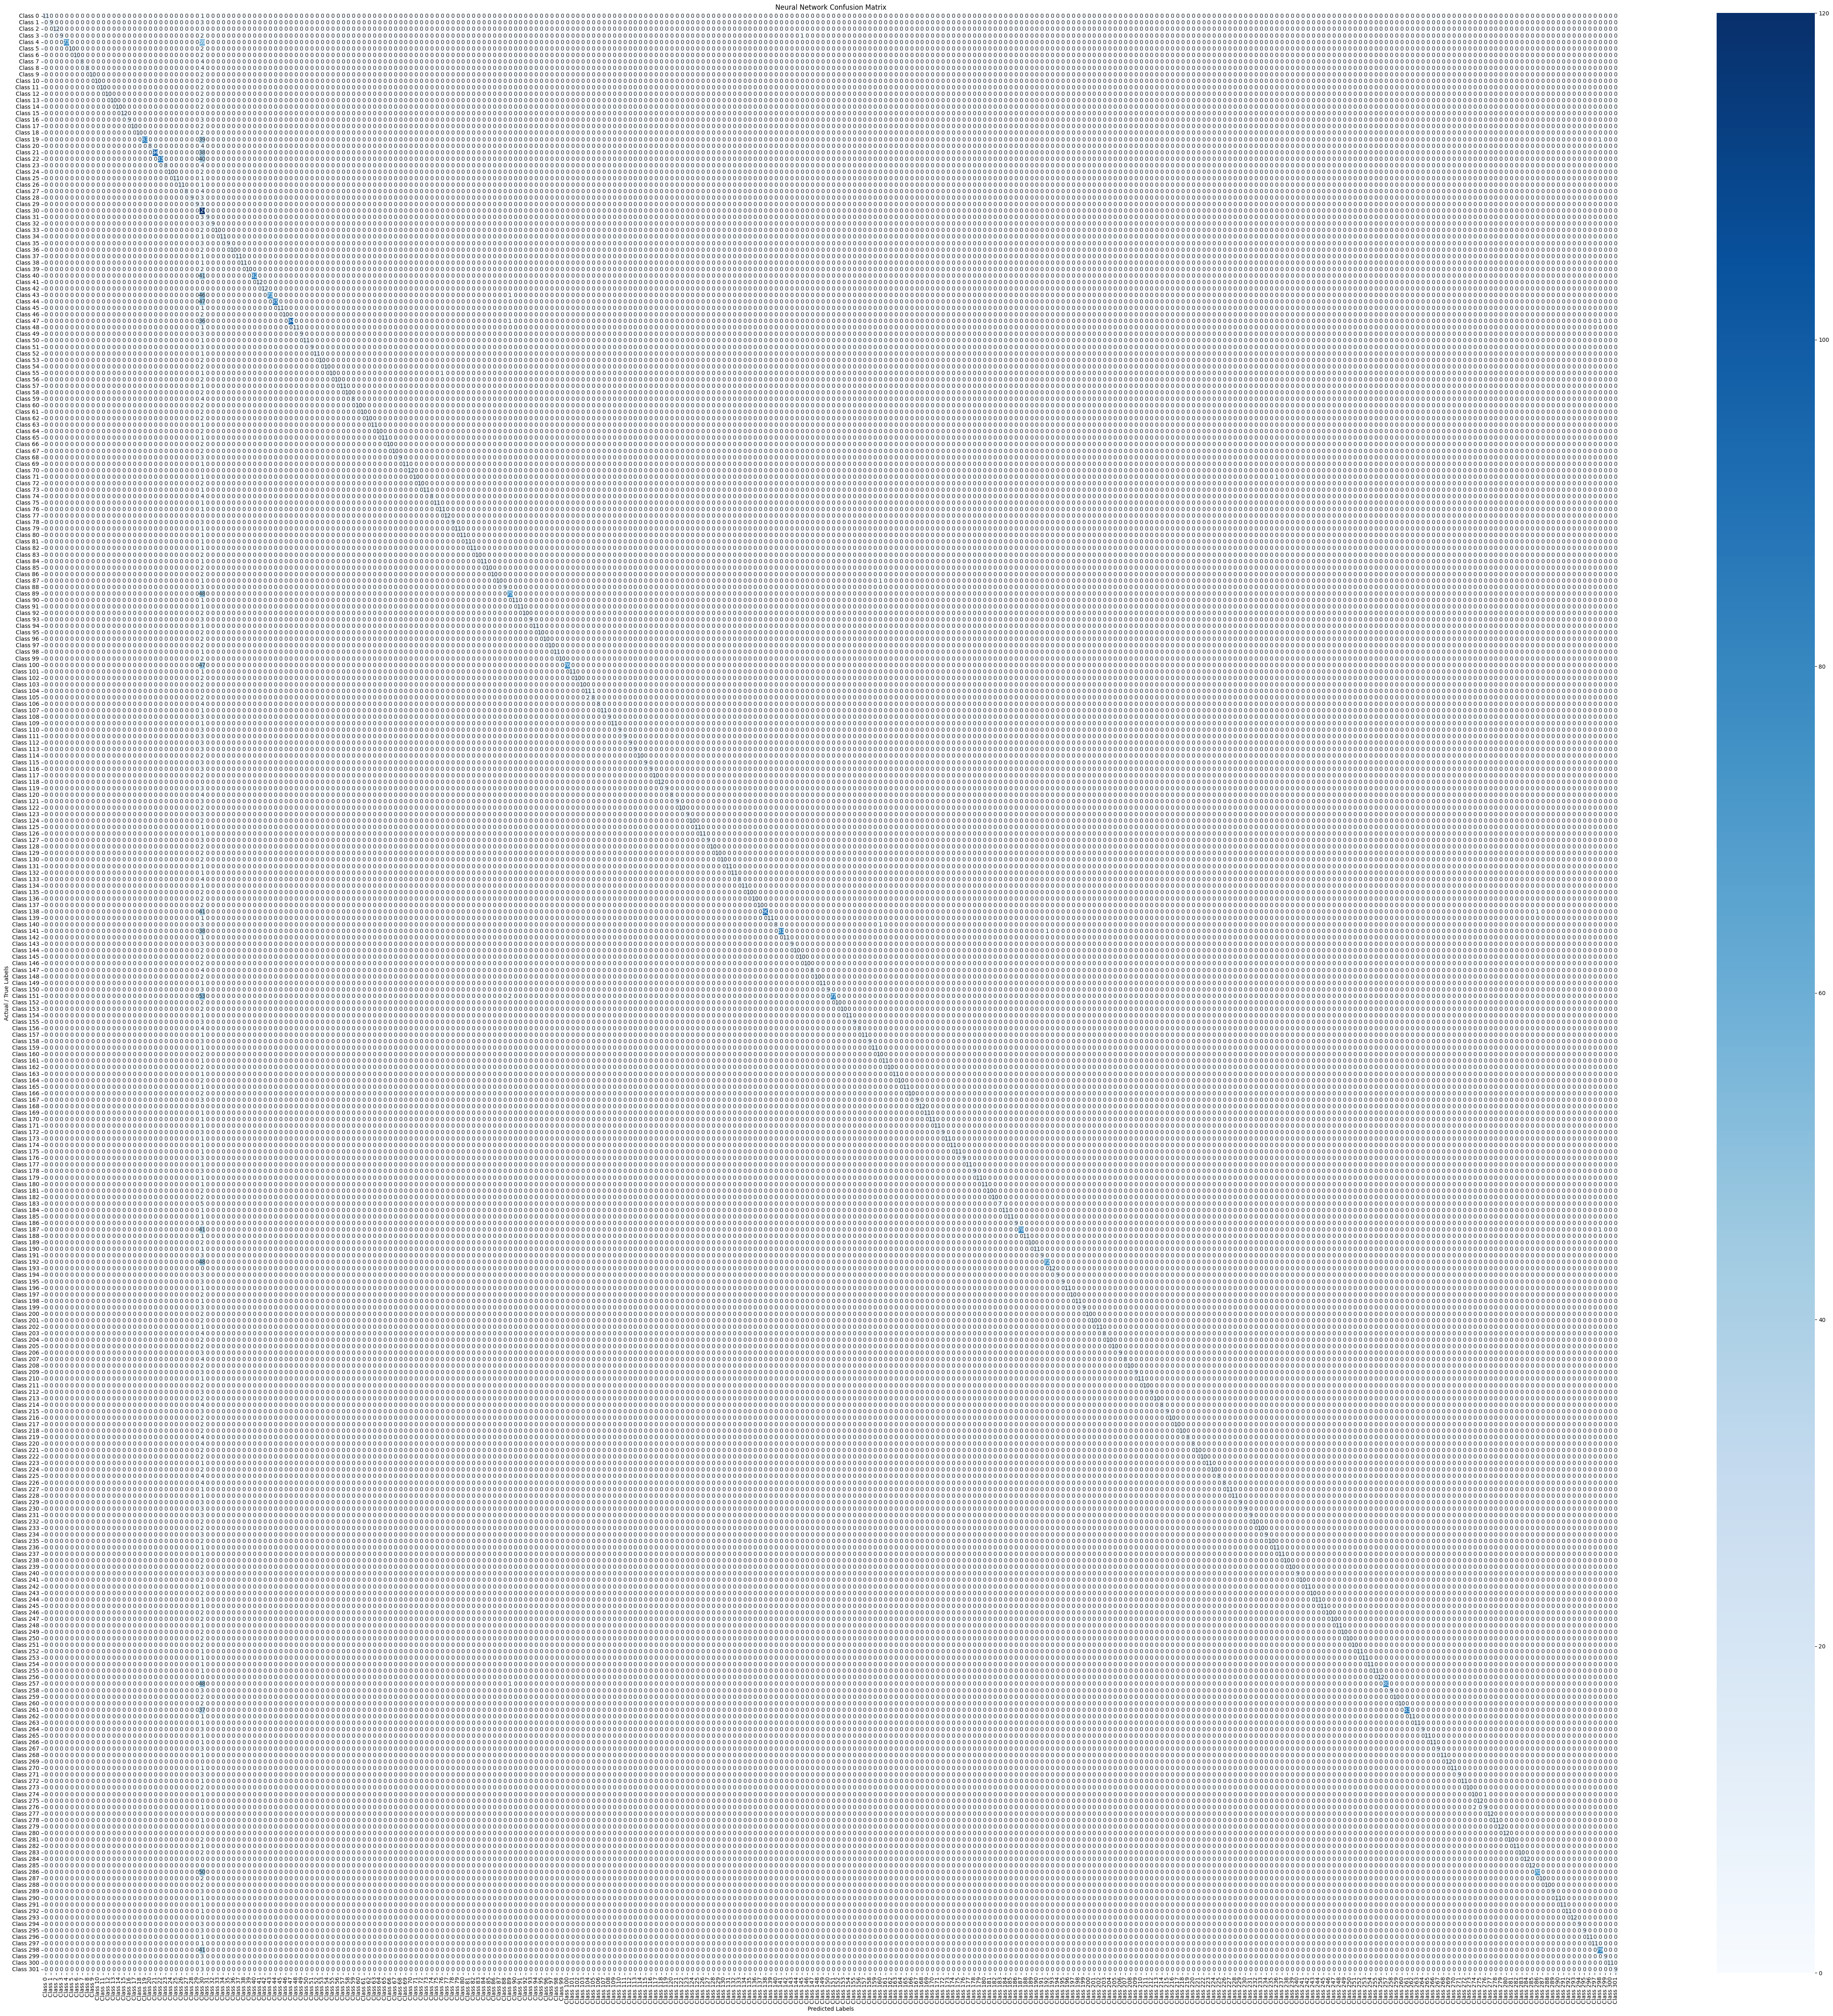

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

import json

NETWORK_NAME = "CNN_3D_Main_07"


cm = np.load(f"E:/Unesp/TCC/Codigo/Metricas/{NETWORK_NAME}_Confusion.npy")
class_enum = []
class_string = []
with open(f"E:/Unesp/TCC/Codigo/Metricas/{NETWORK_NAME}_Labels.json", "r") as f:
    class_enum = json.load(f)
with open(f"E:/Unesp/TCC/Codigo/Metricas/{NETWORK_NAME}_String_Labels.json", "r") as f:
    class_names = json.load(f)

unique_ordered_array = list(dict.fromkeys(class_names))
print(unique_ordered_array[30])

# Set up the matplotlib figure
plt.figure(figsize=(50, 50))

# Create the heatmap
sns.heatmap(
    cm, 
    annot=True,
    fmt='d',              
    cmap='Blues',         
    xticklabels=class_enum, 
    yticklabels=class_enum
)

# Add labels and title
plt.ylabel('Actual / True Labels')
plt.xlabel('Predicted Labels')
plt.title('Neural Network Confusion Matrix')

# Show the plot
plt.tight_layout()
plt.show()

Ar


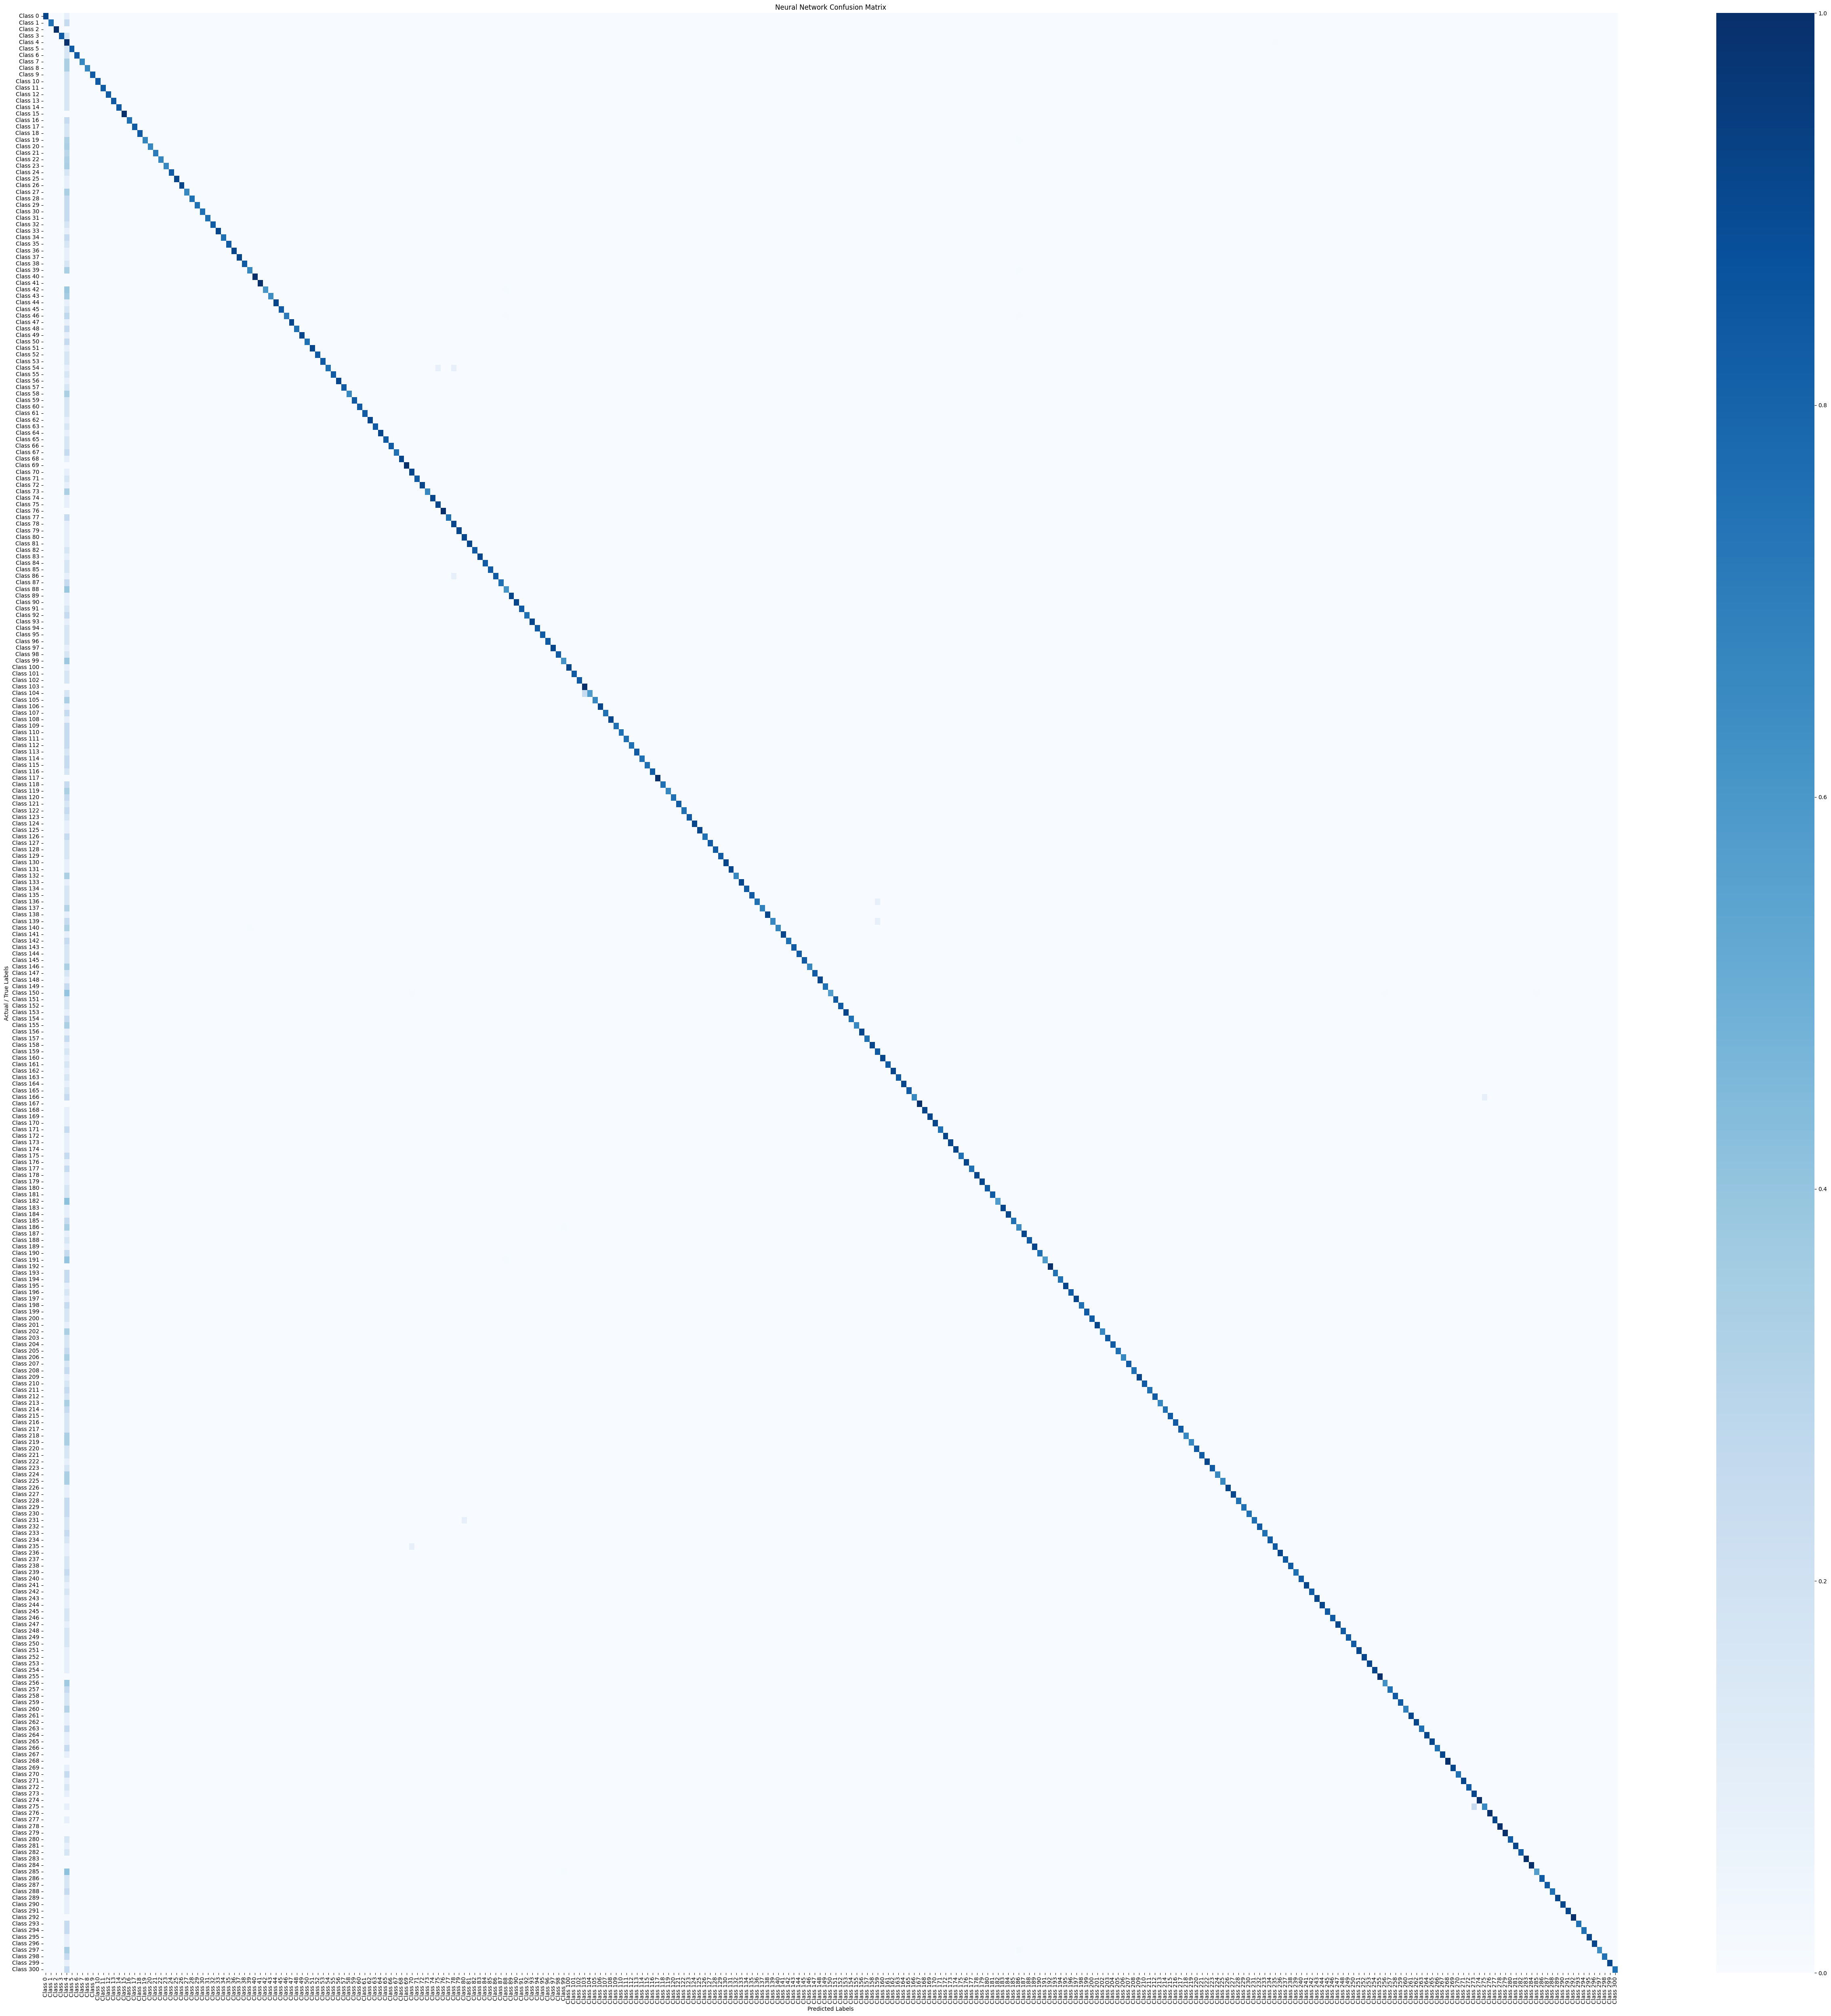

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

import json

NETWORK_NAME = "CNN_3D_Main_08"


cm = np.load(f"E:/Unesp/TCC/Codigo/Metricas/{NETWORK_NAME}_Normalized_Confusion.npy")
class_enum = []
class_string = []
with open(f"E:/Unesp/TCC/Codigo/Metricas/{NETWORK_NAME}_Labels.json", "r") as f:
    class_enum = json.load(f)
with open(f"E:/Unesp/TCC/Codigo/Metricas/{NETWORK_NAME}_String_Labels.json", "r") as f:
    class_names = json.load(f)

unique_ordered_array = list(dict.fromkeys(class_names))
print(unique_ordered_array[4])

# Set up the matplotlib figure
plt.figure(figsize=(50, 50))

# Create the heatmap
sns.heatmap(
    cm, 
    annot=False,
    fmt='.0f',              
    cmap='Blues',         
    xticklabels=class_enum, 
    yticklabels=class_enum
)

# Add labels and title
plt.ylabel('Actual / True Labels')
plt.xlabel('Predicted Labels')
plt.title('Neural Network Confusion Matrix')

# Show the plot
plt.tight_layout()
plt.show()